In [1]:
# step 1 is to import the necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder



In [ ]:
import pandas as pd
import numpy as np

# Creating a dataset with missing values
data = {
    'ID': [1, 2, 3, 4, 5],
    'Name': ['Alice', 'Bob', np.nan, 'David', 'Eve'],
    'Age': [25, np.nan, 30, np.nan, 40],
    'City': ['New York', 'Los Angeles', 'Chicago', np.nan, 'Houston'],
    'Salary': [50000, 60000, np.nan, 80000, 70000]
}
df = pd.DataFrame(data)
print("Original DataFrame with Missing Values:")
print(df)

# Detecting missing values
print("\nMissing values in each column:")
print(df.isnull().sum())
# df_filled = df.fillna(0)
# print(df_filled)

# Dropping rows with missing values
# df_dropped_rows = df.dropna()
# print("\nDataFrame after dropping rows with missing values:")
# print(df_dropped_rows)

# Dropping columns with missing values
# df_dropped_cols = df.dropna(axis=1)
# print("\nDataFrame after dropping columns with missing values:")
# print(df_dropped_cols)

# Filling missing values with specific values
# df_filled = df.fillna({'Age': df['Age'].mean(), 'City': 'Unknown', 'Salary': df['Salary'].median()})
# print("\nDataFrame after filling missing values:")
# print(df_filled)


# df.fillna({'Name':'Unknown', 'Age':df['Age'].mean(), 'City':'Unknown', 'Salary':df['Salary'].median()}, inplace=True)
# print(df)
# use of inplace=True

# 🟢 IMPORTANT: fillna() does not change the DataFrame unless you use inplace=True

Original DataFrame with Missing Values:
   ID   Name   Age         City   Salary
0   1  Alice  25.0     New York  50000.0
1   2    Bob   NaN  Los Angeles  60000.0
2   3    NaN  30.0      Chicago      NaN
3   4  David   NaN          NaN  80000.0
4   5    Eve  40.0      Houston  70000.0

Missing values in each column:
ID        0
Name      1
Age       2
City      1
Salary    1
dtype: int64
   ID     Name        Age         City   Salary
0   1    Alice  25.000000     New York  50000.0
1   2      Bob  31.666667  Los Angeles  60000.0
2   3  Unknown  30.000000      Chicago  65000.0
3   4    David  31.666667      Unknown  80000.0
4   5      Eve  40.000000      Houston  70000.0


✅ Definition

Categorical data = data that consists of names, labels, or categories.
It cannot be measured with numbers, only classified.

🔵 Examples of Categorical Data
✔ 1. Gender

Male

Female

Other

✔ 2. Colors

Red

Blue

Green

✔ 3. City Names

Mumbai

Delhi

Pune

✔ 4. Yes/No type

Yes

No

✔ 5. Occupation

Student

Engineer

Doctor

⭐ Step-by-Step EDA

1️⃣ Load the dataset

In [22]:
import pandas as pd
df = pd.read_csv("ecommerce_customers_unit1.csv")

In [ ]:
2️⃣ View the shape and first rows

In [23]:
df.head()

,customer_id,age,gender,country,signup_date,last_purchase_date,num_orders,total_spent,avg_order_value,recency_days,is_premium_member,device_type,preferred_category,churned
0,10001,56.0,Male,India,2022-01-27,2024-04-27,10,13273.25,1327.32,522,0,NaN,Home,0
1,10002,69.0,Other,UK,2025-01-12,2025-08-01,10,NaN,308.90,61,0,Mobile,Grocery,0
2,10003,46.0,Female,USA,2021-04-25,2021-06-01,5,3411.83,682.37,1583,0,NaN,NaN,0
3,10004,32.0,Male,India,2021-02-23,2023-09-22,5,4502.00,900.40,740,0,NaN,NaN,0
4,10005,60.0,Female,India,2021-06-07,2021-12-11,7,3842.10,548.87,1390,0,Tablet,Books,0


In [24]:
df.tail()

,customer_id,age,gender,country,signup_date,last_purchase_date,num_orders,total_spent,avg_order_value,recency_days,is_premium_member,device_type,preferred_category,churned
600,10358,25.0,Female,India,2023-09-04,2025-06-18,7,NaN,0.00,105,1,Mobile,Electronics,0
601,10117,50.0,Male,USA,2024-05-11,2024-11-08,4,3640.07,910.02,327,0,Mobile,Electronics,0
602,10599,46.0,Male,India,2020-12-01,2024-06-25,6,2176.22,362.70,463,1,Desktop,Electronics,0
603,10442,32.0,Female,UK,2023-12-20,2024-09-20,3,5478.65,1826.22,376,0,Mobile,Home,0
604,10555,44.0,Female,Germany,2024-06-16,2024-12-09,6,5408.13,901.36,296,0,Mobile,Fashion,0


In [25]:
df.shape

(605, 14)

3️⃣ Check basic info
This tells you:
Data types (int, float, object)
Missing values
Memory usage

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         605 non-null    int64  
 1   age                 577 non-null    float64
 2   gender              571 non-null    object 
 3   country             573 non-null    object 
 4   signup_date         605 non-null    object 
 5   last_purchase_date  605 non-null    object 
 6   num_orders          605 non-null    int64  
 7   total_spent         571 non-null    float64
 8   avg_order_value     605 non-null    float64
 9   recency_days        605 non-null    int64  
 10  is_premium_member   605 non-null    int64  
 11  device_type         575 non-null    object 
 12  preferred_category  583 non-null    object 
 13  churned             605 non-null    int64  
dtypes: float64(3), int64(5), object(6)
memory usage: 66.3+ KB


4️⃣ Summary statistics

In [27]:
df.describe()

,customer_id,age,num_orders,total_spent,avg_order_value,recency_days,is_premium_member,churned
count,605.000000,577.000000,605.000000,571.000000,605.000000,605.000000,605.000000,605.000000
mean,10301.439669,44.175043,5.945455,8059.212137,1279.377471,456.029752,0.294215,0.036364
std,173.636071,14.978765,2.332892,10346.781856,1123.841840,405.810389,0.456066,0.187348
min,10001.000000,18.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,10151.000000,32.000000,4.000000,3920.640000,795.780000,128.000000,0.000000,0.000000
50%,10302.000000,45.000000,6.000000,6533.980000,1152.530000,327.000000,0.000000,0.000000
75%,10451.000000,56.000000,7.000000,9523.010000,1615.030000,696.000000,1.000000,0.000000
max,10600.000000,69.000000,13.000000,123891.810000,11431.900000,1685.000000,1.000000,1.000000


In [ ]:
5️⃣ Missing value analysis

In [28]:
df.isnull().sum()

customer_id            0
age                   28
gender                34
country               32
signup_date            0
last_purchase_date     0
num_orders             0
total_spent           34
avg_order_value        0
recency_days           0
is_premium_member      0
device_type           30
preferred_category    22
churned                0
dtype: int64

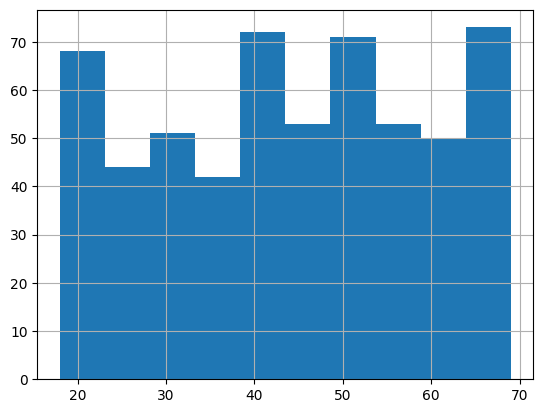

In [29]:
df['age'].hist()
plt.show()

This shows how many missing values are in each column.
Then you decide:

Drop

Fill (mean/median/mode)

Forward-fill/back-fill

In [40]:
# Numerical columns → use mean/median
df['age']=df['age'].fillna(df['age'].median())
df['total_spent']=df['total_spent'].fillna(df['total_spent'].mean())
df['device_type']=df['device_type'].fillna(df['device_type'].mode()[0])

# Categorical columns → use mode
# df['gender']=df['gender'].fillna(df['gender'].mode()[0])
# ✅ Why do we use mode()[0] instead of just mode()?
# 👉 mode() does NOT return a single value
# It returns a Series (a column), not a single item.
# Example:

# df['city'].mode()

# Output looks like:

# 0    delhi
# dtype: object

# This is a Pandas Series, not a single string like "delhi".
# But fillna() requires a single value, not a Series.
# ✔️ So what does mode()[0] do?
# It extracts only the first value from the Series.
# Example:

# df['city'].mode()[0]

# This becomes:

# "delhi"

# Now this is a single value, which fillna() can use.

REMOVING DUPLICATES

In [37]:
df.drop_duplicates(inplace=True)

In [41]:
print(df.head())

   customer_id   age  gender country signup_date last_purchase_date  \
0        10001  56.0    Male   India  2022-01-27         2024-04-27   
1        10002  69.0   Other      UK  2025-01-12         2025-08-01   
2        10003  46.0  Female     USA  2021-04-25         2021-06-01   
3        10004  32.0    Male   India  2021-02-23         2023-09-22   
4        10005  60.0  Female   India  2021-06-07         2021-12-11   

   num_orders   total_spent  avg_order_value  recency_days  is_premium_member  \
0          10  13273.250000          1327.32           522                  0   
1          10   8086.608571           308.90            61                  0   
2           5   3411.830000           682.37          1583                  0   
3           5   4502.000000           900.40           740                  0   
4           7   3842.100000           548.87          1390                  0   

  device_type preferred_category  churned  
0      Mobile               Home        0 

## LABEL ENCODER AND ONE HOT ENCODER

In [ ]:
# Label Encoder and One-Hot Encoder are techniques used to convert categorical 
# (text) data into numerical form, which is required by most machine learning algorithms.

# 1️⃣ Label Encoder
# 🔹 What it does
# Label Encoding converts each unique category into a unique integer.
# 🔹 Example
# Suppose you have a column:

# Color
# Red
# Green
# Blue
# Red

# After Label Encoding:

# Color
# Red   → 2
# Green → 1
# Blue  → 0

# (Exact numbers may vary)

# 🔹 How it works
# Assigns numbers from 0 to n-1
# Each category gets one number
# 🔹 Code Example (Python – scikit-learn)

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
colors = ["Red", "Green", "Blue", "Red"]
encoded = le.fit_transform(colors)
print(encoded)

🔹 When to use

✅ Ordinal data (order matters)
Examples:

Low < Medium < High

Small < Medium < Large

🔹 Problem with Label Encoding

❌ It introduces false order when data is nominal.

Example:

Red = 2, Green = 1, Blue = 0


The model may think:

Red > Green > Blue


(which is meaningless)

2️⃣ One-Hot Encoder
🔹 What it does

One-Hot Encoding converts each category into a binary column (0 or 1).

🔹 Example

Original data:

Color
Red
Green
Blue


After One-Hot Encoding:

Red  Green  Blue
1     0      0
0     1      0
0     0      1

🔹 How it works

Creates new columns

Each column represents one category

Value is 1 if present, else 0

🔹 Code Example
from sklearn.preprocessing import OneHotEncoder
import numpy as np

encoder = OneHotEncoder(sparse=False)
colors = np.array([["Red"], ["Green"], ["Blue"]])
encoded = encoder.fit_transform(colors)
print(encoded)

🔹 When to use

✅ Nominal data (no order)
Examples:

City names

Colors

Country

🔹 Advantage

✔ No false ranking
✔ Models understand categories independently

🔹 Disadvantage

❌ Increases number of columns (curse of dimensionality)

🔥 Key Differences (Exam-Friendly)
Feature	Label Encoder	One-Hot Encoder
Output	Single column	Multiple columns
Order implied	Yes ❌	No ✅
Best for	Ordinal data	Nominal data
Risk	Misleading order	High dimensionality
🧠 Simple Rule to Remember

Order matters? → Label Encoder

Order doesn’t matter? → One-Hot Encoder

If you want, I can also explain this in exam-answer format (5 marks) or with a real ML use case 👍

use please

Got it — you want how to USE Label Encoder and One-Hot Encoder in practice 👍
I’ll explain where, why, and how to use them with clear examples.

✅ When & How to Use Label Encoder
📌 Use Label Encoder when:

The categorical data has a natural order

The model should understand ranking

🔹 Examples of suitable data
Feature	Meaning
Education	High School < Graduate < Post-Graduate
Size	Small < Medium < Large
Risk Level	Low < Medium < High
🔹 Example
Risk
Low
Medium
High
Medium


After Label Encoding:

Low    → 0
Medium → 1
High   → 2

🔹 Why this works

The order Low < Medium < High is meaningful, so numeric ranking helps the model.

🔹 Python Usage
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
risk = ["Low", "Medium", "High", "Medium"]
encoded_risk = le.fit_transform(risk)
print(encoded_risk)

❌ When NOT to use Label Encoder

❌ For nominal data (no order)

Example:

City = Delhi, Mumbai, Chennai


Label Encoding would wrongly imply:

Delhi > Mumbai > Chennai

✅ When & How to Use One-Hot Encoder
📌 Use One-Hot Encoder when:

Categories have no order

Each category is independent

🔹 Examples of suitable data
Feature
City
Color
Country
Department
🔹 Example
City
Delhi
Mumbai
Chennai


After One-Hot Encoding:

Delhi  Mumbai  Chennai
1      0        0
0      1        0
0      0        1

🔹 Why this works

No category is considered greater or smaller than another.

🔹 Python Usage
from sklearn.preprocessing import OneHotEncoder
import numpy as np

ohe = OneHotEncoder(sparse=False)
city = np.array([["Delhi"], ["Mumbai"], ["Chennai"]])
encoded_city = ohe.fit_transform(city)
print(encoded_city)

🧠 Real-Life ML Pipeline Example

Suppose you have this dataset:

Feature	Type	Encoding
Age	Numerical	No encoding
Education Level	Ordinal	Label Encoder
City	Nominal	One-Hot Encoder
Salary	Numerical	No encoding

✔ Use both encoders together depending on column type.

📝 Exam-Ready One-Line Usage Rule

Label Encoder → Ordered categorical data

One-Hot Encoder → Unordered categorical data

If you want, I can:

Show Pandas-based encoding

Explain why tree models sometimes allow label encoding

Give a 5-mark exam answer

Explain Label vs OneHot vs Ordinal Encoder